# Лабораторная работа №2. Методы классификации и нейронные сети
### Отчет по практическому заданию курса «Машинное обучение»

### 1) Введение. Краткое описание целей и задач работы

- **Цель работы:** изучить методы классификации из библиотеки scikit-learn и построить нейронную сеть на TensorFlow, сравнив качество моделей и влияние гиперпараметров.
- **Постановка задачи:**
  1. Выбрать и подготовить датасет для бинарной классификации.
  2. Обучить наивный байесовский классификатор в вариантах GaussianNB, MultinomialNB, ComplementNB и BernoulliNB.
  3. Обучить дерево решений, линейный дискриминантный анализ и метод опорных векторов.
  4. Сравнить модели по Accuracy, Precision, Recall, F1-score и AUC-ROC.
  5. Подобрать гиперпараметры и показать, как они меняют качество.
  6. Построить нейронную сеть на TensorFlow, записать ход обучения в TensorBoard и подобрать скорость обучения и архитектуру 5-кратной кросс-валидацией.
- **Что не входит в работу:** метод k ближайших соседей в этом варианте не рассматривается.
- **Датасет:** Breast Cancer Wisconsin (Original) с Kaggle. Наблюдение — один цитологический образец. Целевая переменная — диагноз: 0 доброкачественная опухоль, 1 злокачественная.


In [1]:
from pathlib import Path
import os
import urllib.request

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import BernoulliNB, ComplementNB, GaussianNB, MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Binarizer, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "output"
TB_DIR = OUTPUT_DIR / "tensorboard"
DATA_PATH = DATA_DIR / "breast-cancer.csv"
DATA_URL = "https://raw.githubusercontent.com/selva86/datasets/master/BreastCancer.csv"

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5

FEATURES = [
    "Cl.thickness",
    "Cell.size",
    "Cell.shape",
    "Marg.adhesion",
    "Epith.c.size",
    "Bare.nuclei",
    "Bl.cromatin",
    "Normal.nucleoli",
    "Mitoses",
]
TARGET = "Class"
LABELS = {
    "Cl.thickness": "Толщина скопления",
    "Cell.size": "Размер клеток",
    "Cell.shape": "Форма клеток",
    "Marg.adhesion": "Краевая адгезия",
    "Epith.c.size": "Размер эпителия",
    "Bare.nuclei": "Голые ядра",
    "Bl.cromatin": "Хроматин",
    "Normal.nucleoli": "Ядрышки",
    "Mitoses": "Митозы",
    "Class": "Диагноз",
}

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TB_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
if not DATA_PATH.exists() or DATA_PATH.stat().st_size == 0:
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

raw = pd.read_csv(DATA_PATH)
display(raw.head())
display(raw.isna().sum().to_frame("пропуски"))
display(raw[TARGET].value_counts().rename({0: "доброкачественная", 1: "злокачественная"}).to_frame("число наблюдений"))


,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0


,пропуски
Id,0
Cl.thickness,0
Cell.size,0
Cell.shape,0
Marg.adhesion,0
Epith.c.size,0
Bare.nuclei,16
Bl.cromatin,0
Normal.nucleoli,0
Mitoses,0


,число наблюдений
Class,
доброкачественная,458
злокачественная,241


### Пояснение к датасету

- **Источник:** Breast Cancer Wisconsin (Original) Data Set, публикация на Kaggle: https://www.kaggle.com/datasets/mariolisboa/breast-cancer-wisconsin-original-data-set. Файл сохранён в `data/breast-cancer.csv`.
- **Объём:** в исходной таблице **699** наблюдений. Пропуски есть только у признака «голые ядра» — **16** значений.
- **Признаки:** девять экспертных оценок от 1 до 10: толщина скопления, однородность размера и формы клеток, краевая адгезия, размер эпителия, голые ядра, хроматин, ядрышки и митозы. Идентификатор образца в модель не входит.
- **Классы:** после удаления пропусков доброкачественных образцов **444**, злокачественных **239**. Положительный класс для Precision и Recall — злокачественная опухоль.
- **Почему набор подходит байесовским моделям:** оценки неотрицательные, поэтому MultinomialNB и ComplementNB применимы напрямую. Для BernoulliNB они бинаризуются, для GaussianNB стандартизируются.


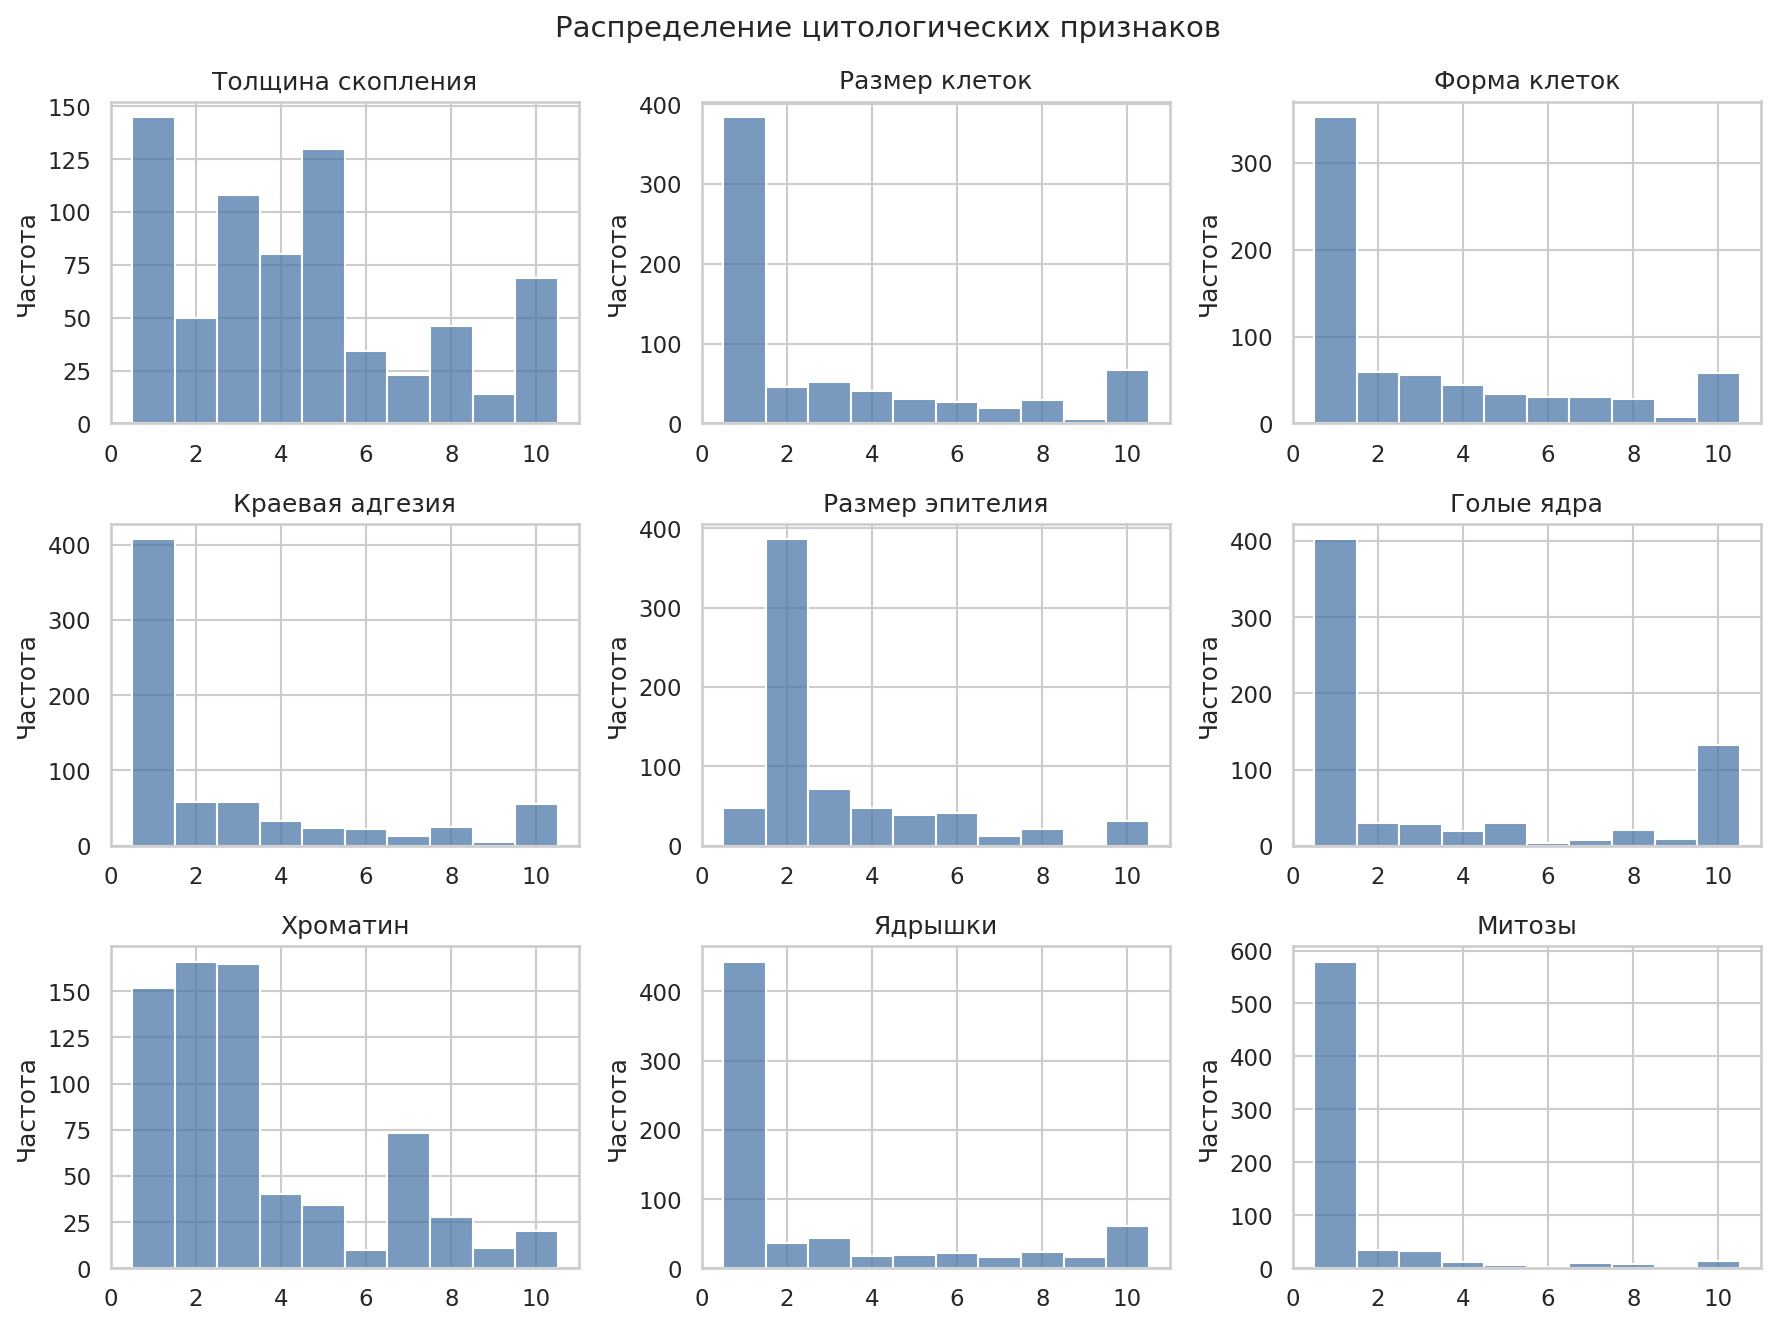

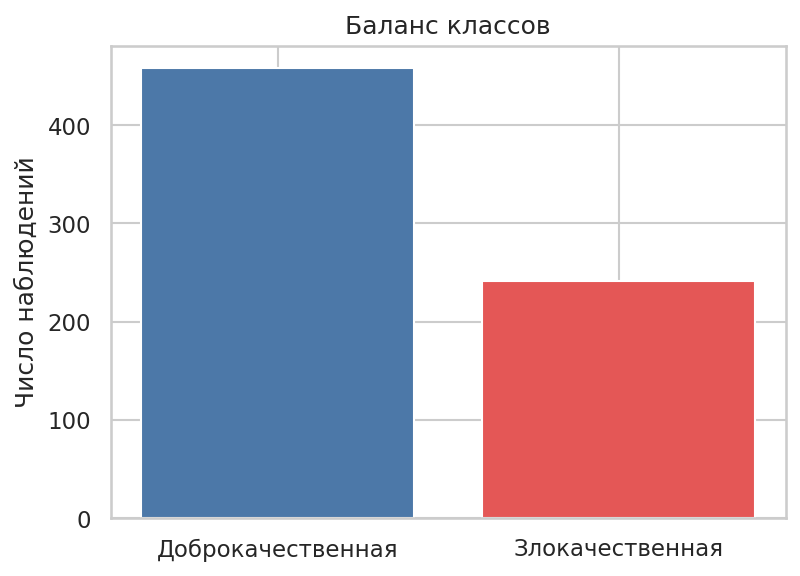

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, column in zip(axes.ravel(), FEATURES):
    sns.histplot(raw[column].dropna(), bins=10, discrete=True, ax=ax, color="#4C78A8")
    ax.set_title(LABELS[column])
    ax.set_xlabel("")
    ax.set_ylabel("Частота")
fig.suptitle("Распределение цитологических признаков", fontsize=14)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_distributions.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 4))
counts = raw[TARGET].value_counts().sort_index()
ax.bar(["Доброкачественная", "Злокачественная"], counts.values, color=["#4C78A8", "#E45756"])
ax.set_ylabel("Число наблюдений")
ax.set_title("Баланс классов")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_class_balance.png", bbox_inches="tight")
plt.show()


### Пояснение к распределениям

- Признаки дискретны и лежат на шкале от 1 до 10. У большинства доброкачественных образцов оценки небольшие, поэтому распределения смещены влево.
- Классы несбалансированы умеренно: доброкачественных случаев больше. Из-за этого одной Accuracy недостаточно, дальше смотрим ещё Precision, Recall, F1 и AUC-ROC.
- На диаграмме баланса видно, что злокачественный класс — меньшинство, но его доля около трети выборки, а не редкое событие.


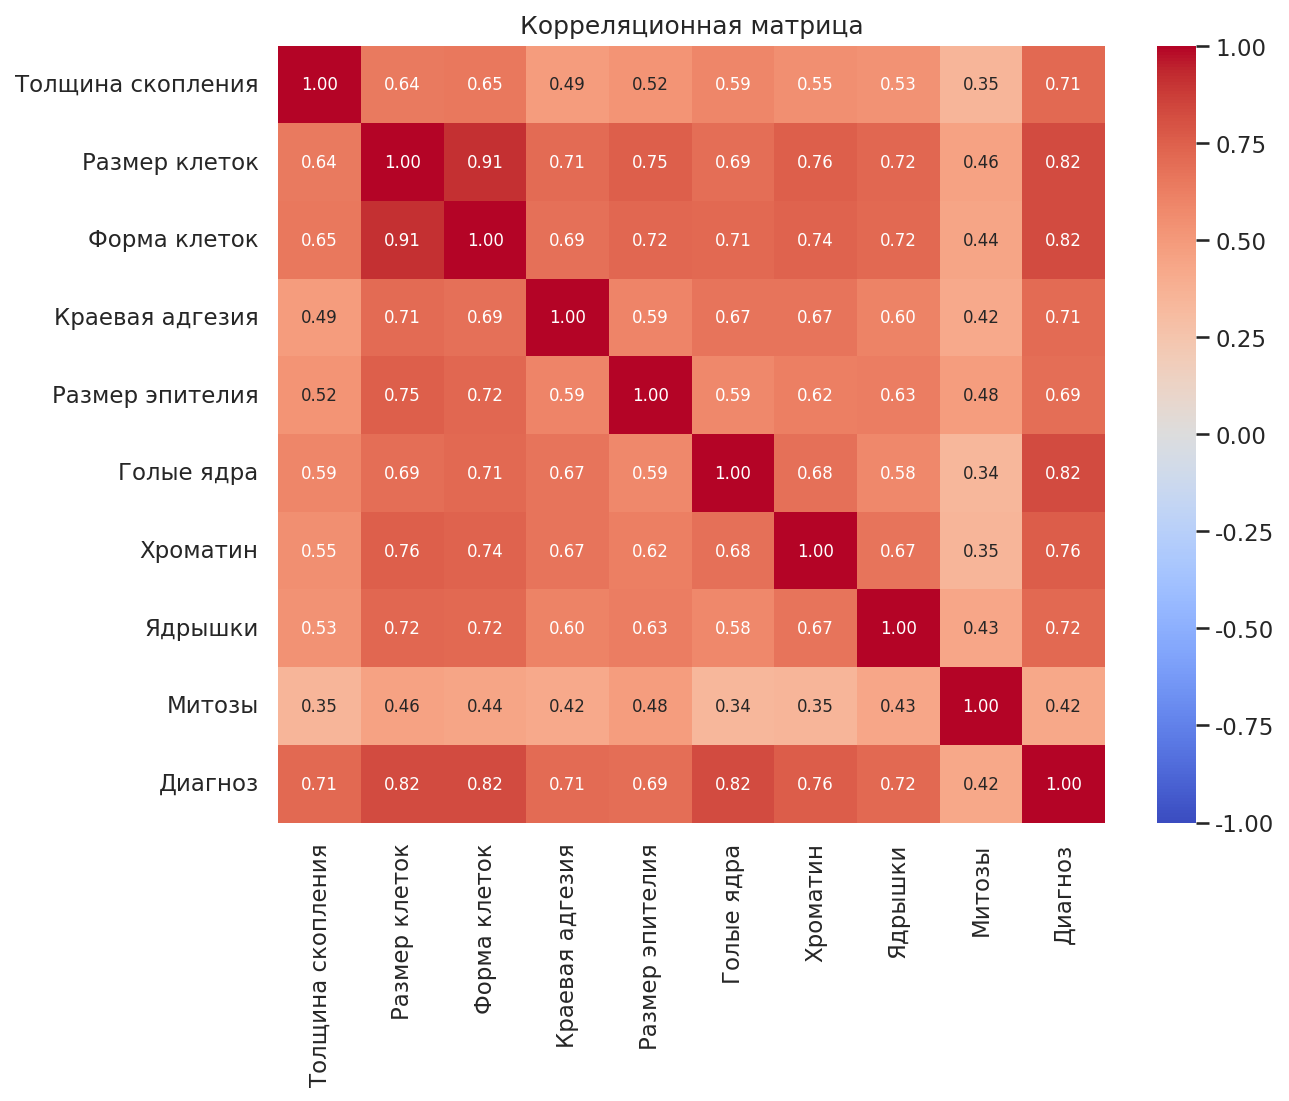

Обучающая выборка: 546
Тестовая выборка: 137
Доля злокачественных в тесте: 0.350


In [4]:
data = raw.dropna().reset_index(drop=True)
x = data[FEATURES]
y = data[TARGET].astype(int)

corr = data[FEATURES + [TARGET]].corr()
corr.rename(index=LABELS, columns=LABELS).to_csv(OUTPUT_DIR / "correlation.csv", encoding="utf-8-sig")
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(
    corr.rename(index=LABELS, columns=LABELS),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Корреляционная матрица")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_correlation.png", bbox_inches="tight")
plt.show()

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
print(f"Обучающая выборка: {len(x_train)}")
print(f"Тестовая выборка: {len(x_test)}")
print(f"Доля злокачественных в тесте: {y_test.mean():.3f}")


### Пояснение к подготовке и разбиению

- Строки с пропуском в «голых ядрах» удалены. Рабочая выборка — **683** наблюдений и **9** признаков.
- С диагнозом сильнее всего связан признак «Голые ядра»: корреляция 0,82. Клеточные признаки связаны и между собой: крупная и неправильная клетка обычно сопровождается другими высокими оценками.
- Выборка разделена стратифицированно 80/20 (`random_state = 42`): **546** наблюдения на обучение и **137** на тест. Доля злокачественных случаев в тесте сохранена.
- Подбор параметров идёт только по обучающей части, 5-кратной стратифицированной кросс-валидацией. Тест используется один раз для итоговых метрик.


In [5]:
def positive_score(model, x_values):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(x_values)
        if getattr(proba, "ndim", 1) == 2 and proba.shape[1] == 2:
            return np.asarray(proba[:, 1], dtype=float)
    if hasattr(model, "decision_function"):
        return np.asarray(model.decision_function(x_values), dtype=float).ravel()
    return np.asarray(model.predict(x_values), dtype=float).ravel()


def classification_metrics(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "AUC_ROC": roc_auc_score(y_true, y_score),
    }


def evaluate_model(name, model, x_values, y_values):
    prediction = model.predict(x_values)
    score = positive_score(model, x_values)
    row = {"Модель": name, **classification_metrics(y_values, prediction, score)}
    return row, score


results = []
test_scores = {}


,Accuracy,Precision,Recall,F1,AUC_ROC,Параметр,CV F1
Модель,,,,,,,
GaussianNB,0.964,0.922,0.979,0.949,0.982,model__var_smoothing=1e-12,0.952
MultinomialNB,0.891,0.884,0.792,0.835,0.888,alpha=0.01,0.856
ComplementNB,0.839,0.741,0.833,0.784,0.888,alpha=0.01,0.813
BernoulliNB,0.956,0.920,0.958,0.939,0.987,"bin__threshold=3, model__alpha=0.1",0.963


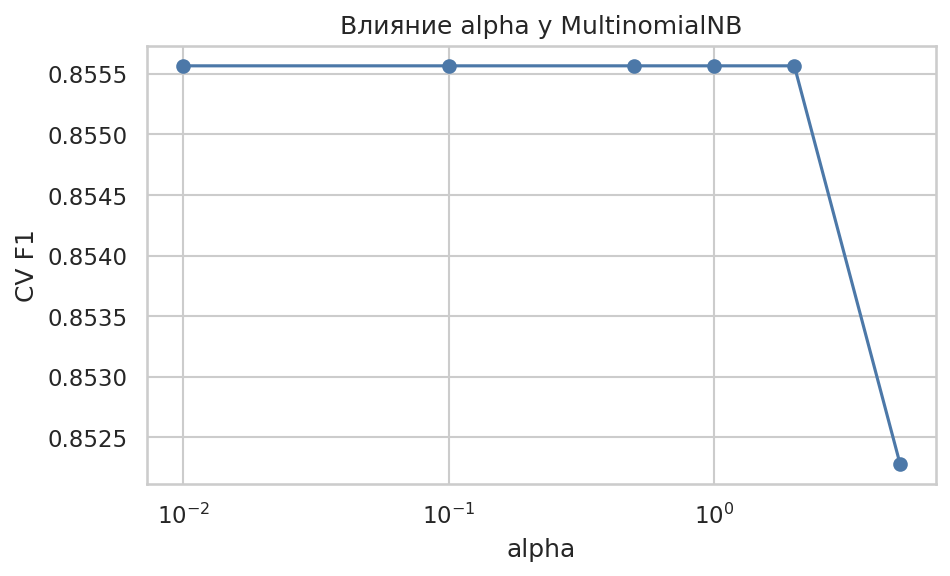

In [6]:
bayes_specs = {
    "GaussianNB": (
        Pipeline([("scaler", StandardScaler()), ("model", GaussianNB())]),
        {"model__var_smoothing": np.logspace(-12, -2, 6)},
    ),
    "MultinomialNB": (
        MultinomialNB(),
        {"alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]},
    ),
    "ComplementNB": (
        ComplementNB(),
        {"alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]},
    ),
    "BernoulliNB": (
        Pipeline([("bin", Binarizer()), ("model", BernoulliNB())]),
        {"bin__threshold": [1, 3, 5, 7], "model__alpha": [0.1, 1.0, 5.0]},
    ),
}

bayes_rows = []
for name, (estimator, grid) in bayes_specs.items():
    search = GridSearchCV(estimator, grid, scoring="f1", cv=cv, n_jobs=1)
    search.fit(x_train, y_train)
    row, score = evaluate_model(name, search.best_estimator_, x_test, y_test)
    row["Параметр"] = ", ".join(f"{key}={value}" for key, value in search.best_params_.items())
    row["CV F1"] = float(search.best_score_)
    bayes_rows.append(row)
    results.append({key: value for key, value in row.items() if key != "Параметр"})
    test_scores[name] = score

bayes_table = pd.DataFrame(bayes_rows).set_index("Модель")
bayes_table.to_csv(OUTPUT_DIR / "metrics_bayes.csv", encoding="utf-8-sig")
display(bayes_table.round(3))

alpha_grid = np.array([0.01, 0.1, 0.5, 1.0, 2.0, 5.0])
alpha_scores = []
for alpha in alpha_grid:
    search = GridSearchCV(MultinomialNB(), {"alpha": [alpha]}, scoring="f1", cv=cv)
    search.fit(x_train, y_train)
    alpha_scores.append(search.best_score_)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(alpha_grid, alpha_scores, marker="o", color="#4C78A8")
ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("CV F1")
ax.set_title("Влияние alpha у MultinomialNB")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_nb_alpha.png", bbox_inches="tight")
plt.show()


### Пояснение к наивному байесовскому классификатору

- **Идея метода.** Признак считается условно независимым при известном классе. Для непрерывных оценок это GaussianNB, для неотрицательных частотоподобных оценок — MultinomialNB и ComplementNB, для бинарных индикаторов — BernoulliNB.
- **Настройка.** У GaussianNB перебирался `var_smoothing`, у MultinomialNB и ComplementNB — сглаживание `alpha`, у BernoulliNB — одновременно порог бинаризации и `alpha`. Критерий выбора — средний F1 на кросс-валидации.
- **Результат на тесте.** Лучший из четырёх вариантов — **GaussianNB**: Accuracy = 0,964, Precision = 0,922, Recall = 0,979, F1 = 0,949, AUC-ROC = 0,982.
- **Влияние alpha.** На графике F1 MultinomialNB меняется слабо: при таких коротких и уже положительных признаках сглаживание не перестраивает решающее правило. Разница вариантов Байеса заметнее, чем разница соседних значений alpha.


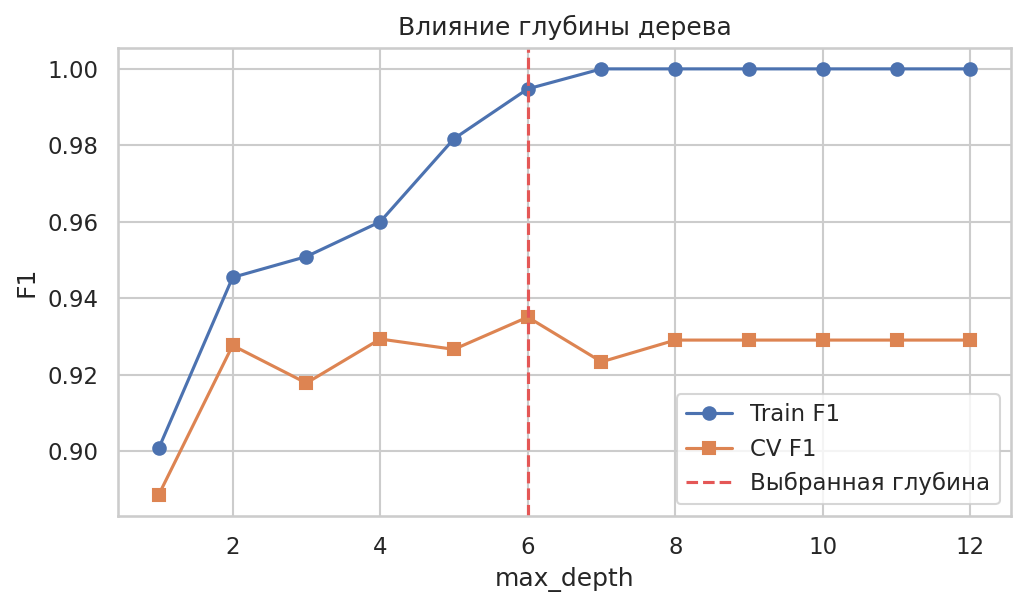

,Accuracy,Precision,Recall,F1,AUC_ROC,Параметр
Модель,,,,,,
Decision Tree,0.956,0.92,0.958,0.939,0.957,"max_depth=6, min_samples_leaf=1"


,важность
Форма клеток,0.742
Голые ядра,0.126
Размер клеток,0.048
Толщина скопления,0.044
Хроматин,0.015
Краевая адгезия,0.014
Ядрышки,0.006
Размер эпителия,0.004
Митозы,0.000


In [7]:
depth_rows = []
for depth in range(1, 13):
    search = GridSearchCV(
        DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE),
        {"min_samples_leaf": [1]},
        scoring="f1",
        cv=cv,
    )
    search.fit(x_train, y_train)
    train_pred = search.predict(x_train)
    depth_rows.append(
        {
            "max_depth": depth,
            "CV F1": search.best_score_,
            "Train F1": f1_score(y_train, train_pred),
        }
    )
depth_table = pd.DataFrame(depth_rows)

tree_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {"max_depth": list(range(1, 13)), "min_samples_leaf": [1, 5, 10]},
    scoring="f1",
    cv=cv,
)
tree_search.fit(x_train, y_train)
tree_row, tree_score = evaluate_model("Decision Tree", tree_search.best_estimator_, x_test, y_test)
tree_row["Параметр"] = ", ".join(f"{key}={value}" for key, value in tree_search.best_params_.items())
results.append({key: value for key, value in tree_row.items() if key != "Параметр"})
test_scores["Decision Tree"] = tree_score

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(depth_table["max_depth"], depth_table["Train F1"], marker="o", label="Train F1")
ax.plot(depth_table["max_depth"], depth_table["CV F1"], marker="s", label="CV F1")
ax.axvline(tree_search.best_params_["max_depth"], color="#E45756", linestyle="--", label="Выбранная глубина")
ax.set_xlabel("max_depth")
ax.set_ylabel("F1")
ax.set_title("Влияние глубины дерева")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_tree_depth.png", bbox_inches="tight")
plt.show()

display(pd.DataFrame([tree_row]).set_index("Модель").round(3))
importances = pd.Series(
    tree_search.best_estimator_.feature_importances_, index=[LABELS[name] for name in FEATURES]
).sort_values(ascending=False)
display(importances.round(3).to_frame("важность"))


### Пояснение к дереву решений

- **Идея метода.** Дерево последовательно делит образцы по порогам признаков. Глубина и минимальное число объектов в листе ограничивают дробление выборки.
- **Настройка.** Перебраны `max_depth` от 1 до 12 и `min_samples_leaf` из множества 1, 5 и 10. На графике train F1 растёт вместе с глубиной и выходит на 1, а CV F1 после небольшой глубины почти не улучшается: глубокое дерево запоминает обучающие образцы.
- **Выбранные параметры:** max_depth=6, min_samples_leaf=1. На тесте Accuracy = 0,956, Precision = 0,920, Recall = 0,958, F1 = 0,939, AUC-ROC = 0,957.
- **Важности.** Наибольший вклад дают признаки, которые уже были сильнее всего связаны с диагнозом на корреляционной матрице. Остальные оценки дерево использует как уточнение на отдельных ветках.


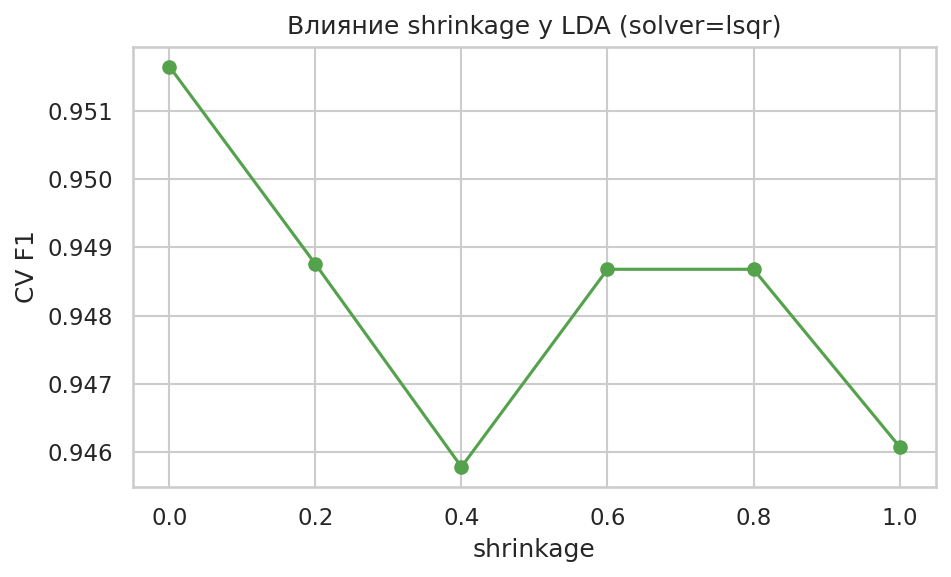

,Accuracy,Precision,Recall,F1,AUC_ROC,Параметр
Модель,,,,,,
LDA,0.942,0.917,0.917,0.917,0.99,"solver=svd, shrinkage=None"


In [8]:
shrinkage_grid = np.linspace(0, 1, 6)
shrinkage_scores = []
for shrinkage in shrinkage_grid:
    search = GridSearchCV(
        LinearDiscriminantAnalysis(solver="lsqr", shrinkage=float(shrinkage)),
        {"solver": ["lsqr"]},
        scoring="f1",
        cv=cv,
    )
    search.fit(x_train, y_train)
    shrinkage_scores.append(search.best_score_)

lda_candidates = []
for solver, shrinkage in (("svd", None), ("lsqr", 0.0), ("lsqr", 0.2), ("lsqr", 0.5), ("lsqr", 0.8), ("lsqr", 1.0)):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis(solver=solver, shrinkage=shrinkage)),
    ])
    fold_scores = []
    for train_index, valid_index in cv.split(x_train, y_train):
        fold_model = clone(model)
        fold_model.fit(x_train.iloc[train_index], y_train.iloc[train_index])
        prediction = fold_model.predict(x_train.iloc[valid_index])
        fold_scores.append(f1_score(y_train.iloc[valid_index], prediction))
    lda_candidates.append({"solver": solver, "shrinkage": shrinkage, "CV F1": float(np.mean(fold_scores)), "model": model})

lda_best = max(lda_candidates, key=lambda item: item["CV F1"])
lda_best["model"].fit(x_train, y_train)
lda_row, lda_score = evaluate_model("LDA", lda_best["model"], x_test, y_test)
lda_row["Параметр"] = f"solver={lda_best['solver']}, shrinkage={lda_best['shrinkage']}"
results.append({key: value for key, value in lda_row.items() if key != "Параметр"})
test_scores["LDA"] = lda_score

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(shrinkage_grid, shrinkage_scores, marker="o", color="#54A24B")
ax.set_xlabel("shrinkage")
ax.set_ylabel("CV F1")
ax.set_title("Влияние shrinkage у LDA (solver=lsqr)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_lda_shrinkage.png", bbox_inches="tight")
plt.show()
display(pd.DataFrame([lda_row]).set_index("Модель").round(3))


### Пояснение к линейному дискриминантному анализу

- **Идея метода.** LDA ищет линейную проекцию, которая лучше всего разделяет классы, и относит образец к классу с большей апостериорной вероятностью. Параметр `shrinkage` сжимает оценку ковариационной матрицы, если признаки коррелируют.
- **Настройка.** Сравнены solver `svd` без сжатия и solver `lsqr` при shrinkage от 0 до 1. График показывает, что сжатие ковариации меняет CV F1 немного: признаков всего девять, а наблюдений несколько сотен, поэтому оценка ковариации и без сжатия устойчива.
- **Выбранные параметры:** solver=svd, shrinkage=None. На тесте Accuracy = 0,942, Precision = 0,917, Recall = 0,917, F1 = 0,917, AUC-ROC = 0,990.


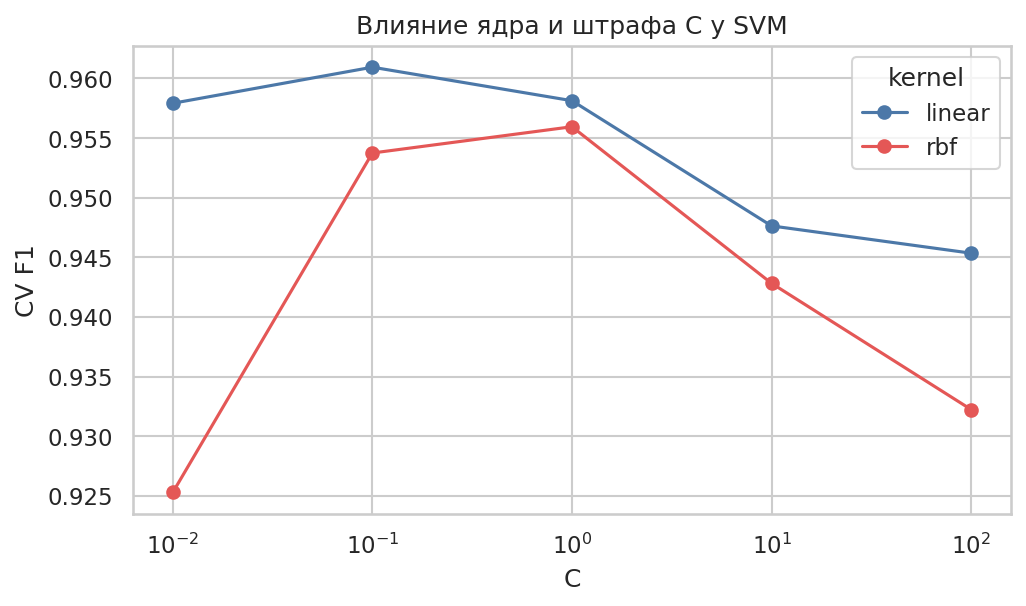

kernel,linear,rbf
C,,
0.01,0.958,0.925
0.10,0.961,0.954
1.00,0.958,0.956
10.00,0.948,0.943
100.00,0.945,0.932


,Accuracy,Precision,Recall,F1,AUC_ROC,Параметр
Модель,,,,,,
SVM,0.956,0.92,0.958,0.939,0.993,"kernel=linear, C=0.1"


In [9]:
c_grid = np.logspace(-2, 2, 5)
svm_rows = []
for kernel in ("linear", "rbf"):
    for c_value in c_grid:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel=kernel, C=float(c_value), random_state=RANDOM_STATE)),
        ])
        fold_scores = []
        for train_index, valid_index in cv.split(x_train, y_train):
            fold_model = clone(model)
            fold_model.fit(x_train.iloc[train_index], y_train.iloc[train_index])
            prediction = fold_model.predict(x_train.iloc[valid_index])
            fold_scores.append(f1_score(y_train.iloc[valid_index], prediction))
        svm_rows.append({"kernel": kernel, "C": float(c_value), "CV F1": float(np.mean(fold_scores))})

svm_table = pd.DataFrame(svm_rows)
best_svm = svm_table.sort_values("CV F1", ascending=False).iloc[0]
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel=best_svm["kernel"], C=float(best_svm["C"]), random_state=RANDOM_STATE)),
])
svm_model.fit(x_train, y_train)
svm_row, svm_score = evaluate_model("SVM", svm_model, x_test, y_test)
svm_row["Параметр"] = f"kernel={best_svm['kernel']}, C={best_svm['C']}"
results.append({key: value for key, value in svm_row.items() if key != "Параметр"})
test_scores["SVM"] = svm_score

fig, ax = plt.subplots(figsize=(7, 4.2))
for kernel, color in (("linear", "#4C78A8"), ("rbf", "#E45756")):
    part = svm_table[svm_table["kernel"] == kernel]
    ax.plot(part["C"], part["CV F1"], marker="o", color=color, label=kernel)
ax.set_xscale("log")
ax.set_xlabel("C")
ax.set_ylabel("CV F1")
ax.set_title("Влияние ядра и штрафа C у SVM")
ax.legend(title="kernel")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_svm_c.png", bbox_inches="tight")
plt.show()
display(svm_table.pivot(index="C", columns="kernel", values="CV F1").round(3))
display(pd.DataFrame([svm_row]).set_index("Модель").round(3))


### Пояснение к методу опорных векторов

- **Идея метода.** SVM проводит границу с максимальным зазором. Параметр `C` задаёт штраф за ошибки: малое `C` делает границу более гладкой, большое — подгоняет её к обучающим точкам. Ядро `linear` строит линейную границу, `rbf` — нелинейную.
- **Настройка.** Для обоих ядер перебраны значения `C` от 0,01 до 100. Перед обучением признаки стандартизованы, потому что штраф зависит от масштаба.
- **Выбранные параметры:** kernel=linear, C=0.1. На тесте Accuracy = 0,956, Precision = 0,920, Recall = 0,958, F1 = 0,939, AUC-ROC = 0,993.
- **Влияние C.** На графике оба ядра быстро выходят на плато. Слишком маленький штраф недобрабатывает злокачественные случаи, а рост `C` после единицы почти не повышает CV F1.


,Accuracy,Precision,Recall,F1,AUC_ROC,CV F1
Модель,,,,,,
GaussianNB,0.964,0.922,0.979,0.949,0.982,0.952
MultinomialNB,0.891,0.884,0.792,0.835,0.888,0.856
ComplementNB,0.839,0.741,0.833,0.784,0.888,0.813
BernoulliNB,0.956,0.920,0.958,0.939,0.987,0.963
Decision Tree,0.956,0.920,0.958,0.939,0.957,NaN
LDA,0.942,0.917,0.917,0.917,0.990,NaN
SVM,0.956,0.920,0.958,0.939,0.993,NaN


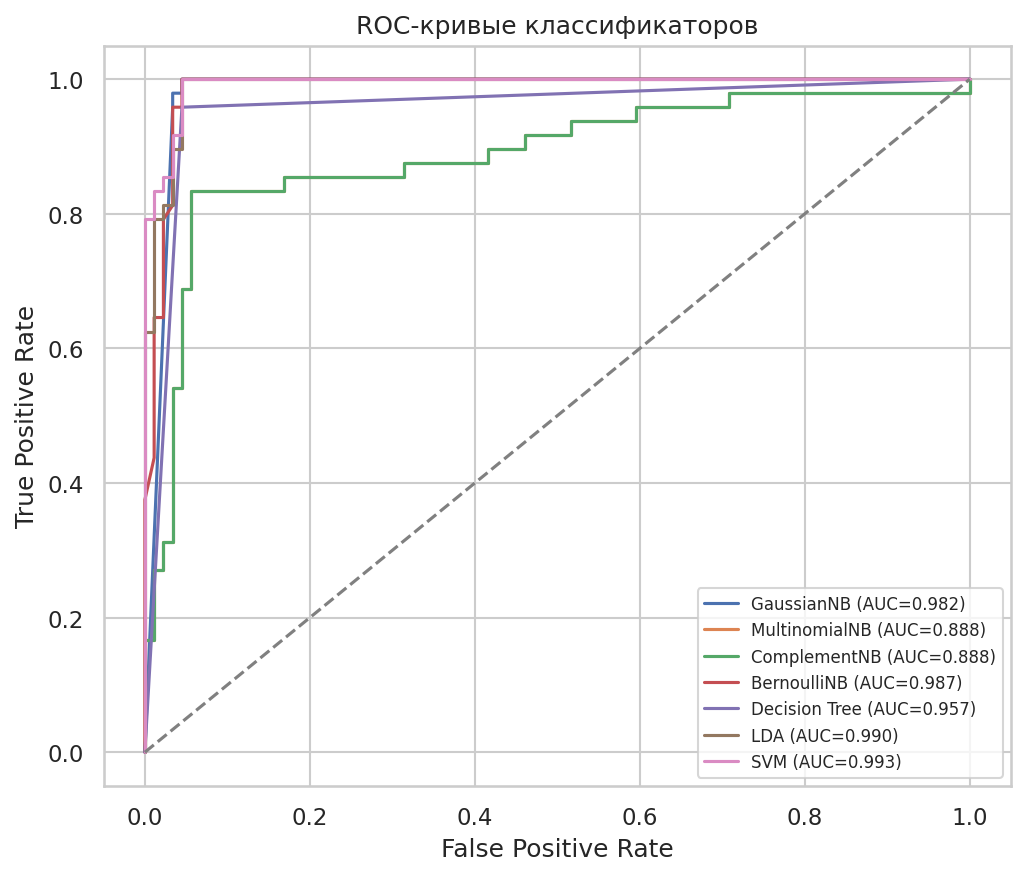

In [10]:
classical = pd.DataFrame(results).set_index("Модель")
classical.to_csv(OUTPUT_DIR / "metrics_classical.csv", encoding="utf-8-sig")
display(classical.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
for name, score in test_scores.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-кривые классификаторов")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "08_roc_classical.png", bbox_inches="tight")
plt.show()


### Пояснение к сравнению классических моделей

- Итоговая таблица собрана по одной и той же тестовой выборке. Положительный класс — злокачественная опухоль, поэтому Recall показывает, какую долю больных образцов модель не пропускает.
- Среди классических моделей по тестовому F1 лидирует **GaussianNB**: Accuracy = 0,964, Precision = 0,922, Recall = 0,979, F1 = 0,949, AUC-ROC = 0,982. ROC-кривые лежат высоко над диагональю: настроенные методы отделяют классы уверенно, а не случайно.
- Accuracy у всех моделей выше 0,9, но выбирать модель только по ней нельзя: при преобладании доброкачественных образцов даже осторожный классификатор получает высокую долю верных ответов. Поэтому дальше нейросеть сравнивается по всему набору метрик.


In [11]:
scaler_nn = StandardScaler()
x_train_nn = scaler_nn.fit_transform(x_train)
x_test_nn = scaler_nn.transform(x_test)


def make_network(hidden, activation, learning_rate):
    tf.keras.backend.clear_session()
    layers = [tf.keras.layers.Input(shape=(x_train_nn.shape[1],))]
    for units in hidden:
        layers.append(tf.keras.layers.Dense(units, activation=activation))
        layers.append(tf.keras.layers.Dropout(0.2))
    layers.append(tf.keras.layers.Dense(1, activation="sigmoid"))
    model = tf.keras.Sequential(layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def fit_network(hidden, activation, learning_rate, epochs, batch_size, log_name, validation_data=None, validation_split=None):
    model = make_network(hidden, activation, learning_rate)
    callbacks = [tf.keras.callbacks.TensorBoard(log_dir=str(TB_DIR / log_name), histogram_freq=0, write_graph=False, update_freq="epoch")]
    fit_kwargs = {"epochs": epochs, "batch_size": batch_size, "callbacks": callbacks, "verbose": 0}
    if validation_data is not None:
        fit_kwargs["validation_data"] = validation_data
    elif validation_split is not None:
        fit_kwargs["validation_split"] = validation_split
    history = model.fit(x_train_nn, y_train, **fit_kwargs)
    return model, history


baseline_model, baseline_history = fit_network((8,), "relu", 1e-3, 40, 32, "baseline_epochs", validation_split=0.2)

experiment_rows = []
for epochs in (10, 20, 40):
    model, _ = fit_network((8,), "relu", 1e-3, epochs, 32, f"epochs_{epochs}", validation_split=0.2)
    probability = model.predict(x_test_nn, verbose=0).ravel()
    prediction = (probability >= 0.5).astype(int)
    experiment_rows.append({"Эксперимент": "эпохи", "Значение": str(epochs), **classification_metrics(y_test, prediction, probability)})

for batch_size in (16, 32, 64):
    model, _ = fit_network((8,), "relu", 1e-3, 25, batch_size, f"batch_{batch_size}", validation_split=0.2)
    probability = model.predict(x_test_nn, verbose=0).ravel()
    prediction = (probability >= 0.5).astype(int)
    experiment_rows.append({"Эксперимент": "batch", "Значение": str(batch_size), **classification_metrics(y_test, prediction, probability)})

for hidden in ((8,), (32, 16), (32, 16, 8)):
    model, _ = fit_network(hidden, "relu", 1e-3, 25, 32, "arch_" + "_".join(map(str, hidden)), validation_split=0.2)
    probability = model.predict(x_test_nn, verbose=0).ravel()
    prediction = (probability >= 0.5).astype(int)
    experiment_rows.append({"Эксперимент": "архитектура", "Значение": str(hidden), **classification_metrics(y_test, prediction, probability)})

for activation in ("relu", "tanh"):
    model, _ = fit_network((8,), activation, 1e-3, 25, 32, f"activation_{activation}", validation_split=0.2)
    probability = model.predict(x_test_nn, verbose=0).ravel()
    prediction = (probability >= 0.5).astype(int)
    experiment_rows.append({"Эксперимент": "активация", "Значение": activation, **classification_metrics(y_test, prediction, probability)})

nn_experiments = pd.DataFrame(experiment_rows)
nn_experiments.to_csv(OUTPUT_DIR / "metrics_nn_experiments.csv", index=False, encoding="utf-8-sig")
display(nn_experiments.round(3))


,Эксперимент,Значение,Accuracy,Precision,Recall,F1,AUC_ROC
0,эпохи,10,0.971,0.923,1.000,0.960,0.997
1,эпохи,20,0.964,0.922,0.979,0.949,0.993
2,эпохи,40,0.964,0.922,0.979,0.949,0.992
3,batch,16,0.956,0.920,0.958,0.939,0.993
4,batch,32,0.964,0.922,0.979,0.949,0.990
5,batch,64,0.949,0.936,0.917,0.926,0.996
6,архитектура,"(8,)",0.964,0.922,0.979,0.949,0.992
7,архитектура,"(32, 16)",0.964,0.922,0.979,0.949,0.992
8,архитектура,"(32, 16, 8)",0.971,0.923,1.000,0.960,0.992
9,активация,relu,0.964,0.922,0.979,0.949,0.993


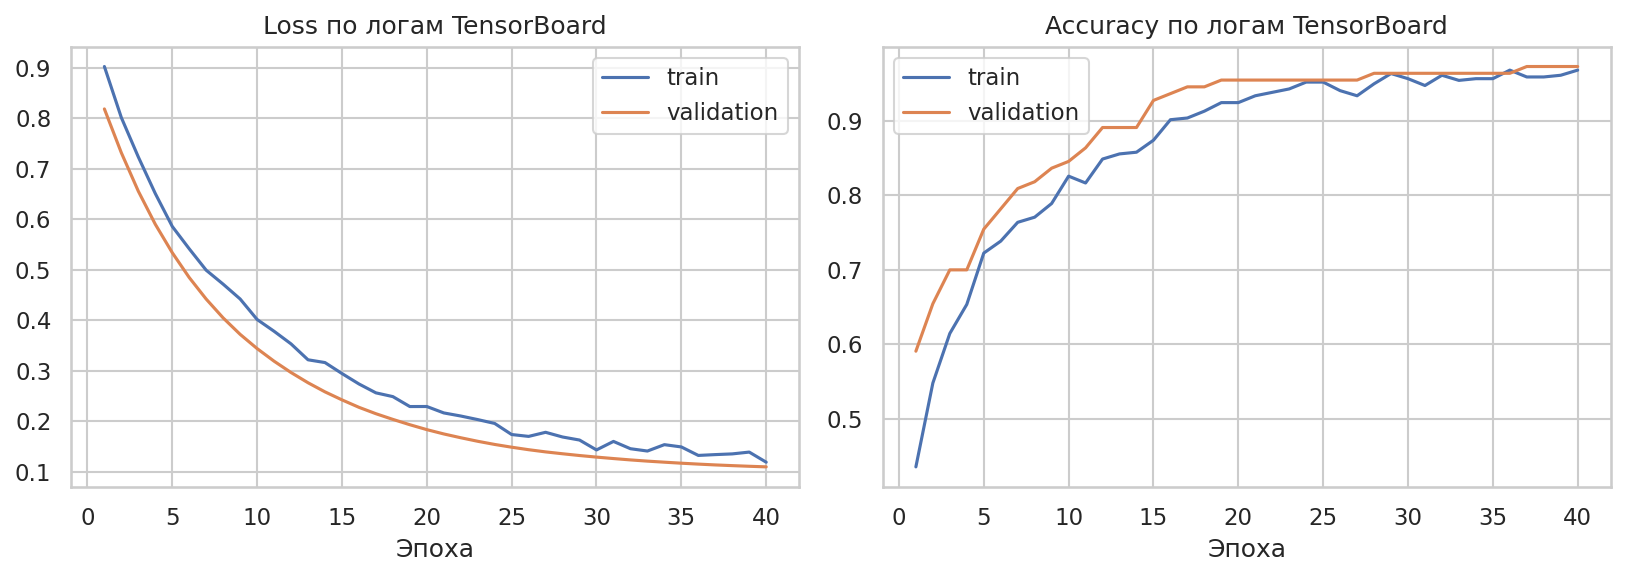

In [12]:
def read_scalar(logdir, tag_options):
    logdir = Path(logdir)
    folders = [logdir]
    if logdir.exists():
        folders.extend(path for path in logdir.rglob("*") if path.is_dir())
    for folder in folders:
        if not list(folder.glob("events.out.tfevents*")):
            continue
        accumulator = EventAccumulator(str(folder))
        accumulator.Reload()
        tags = accumulator.Tags().get("scalars", [])
        for tag in tag_options:
            if tag in tags:
                events = accumulator.Scalars(tag)
                return [event.step for event in events], [event.value for event in events]
    return [], []


train_steps, train_loss = read_scalar(TB_DIR / "baseline_epochs", ["epoch_loss"])
_, train_accuracy = read_scalar(TB_DIR / "baseline_epochs", ["epoch_accuracy"])
val_steps, val_loss = read_scalar(TB_DIR / "baseline_epochs", ["epoch_val_loss", "val_loss"])
_, val_accuracy = read_scalar(TB_DIR / "baseline_epochs", ["epoch_val_accuracy", "val_accuracy"])

if not train_steps:
    train_steps = list(range(1, len(baseline_history.history["loss"]) + 1))
    train_loss = baseline_history.history["loss"]
    train_accuracy = baseline_history.history["accuracy"]
    val_loss = baseline_history.history["val_loss"]
    val_accuracy = baseline_history.history["val_accuracy"]
    val_steps = train_steps

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(train_steps, train_loss, label="train")
if val_steps:
    axes[0].plot(val_steps, val_loss, label="validation")
axes[0].set_title("Loss по логам TensorBoard")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[1].plot(train_steps, train_accuracy, label="train")
if val_steps:
    axes[1].plot(val_steps, val_accuracy, label="validation")
axes[1].set_title("Accuracy по логам TensorBoard")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "09_tensorboard_curves.png", bbox_inches="tight")
plt.show()


### Пояснение к нейронной сети и TensorBoard

- **Архитектура базовой сети.** Полносвязная сеть: вход из 9 стандартизованных признаков, скрытый слой на 8 нейронов с ReLU, Dropout 0,2 и выходной нейрон с сигмоидой. Функция потерь — бинарная кросс-энтропия, оптимизатор — Adam со скоростью обучения 0,001.
- **Эксперименты.** Отдельно менялись число эпох (10, 20, 40), размер батча (16, 32, 64), глубина сети и функция активации скрытого слоя (ReLU или tanh). Каждое обучение писало логи TensorBoard в `output/tensorboard`.
- **Кривые.** График loss и accuracy прочитан из логов TensorBoard базового запуска на 40 эпох. Обучение и проверка на отложенной части обучающей выборки расходятся слабо: на этой небольшой таблице сеть быстро выходит на плато и не показывает длинного переобучения.
- **Эффект параметров.** Увеличение числа эпох после 20 почти не меняет тестовые метрики. Размер батча и замена ReLU на tanh также дают близкие F1. Более глубокая сеть не получает заметного преимущества: признаков мало, а зависимость диагноза от них близка к той, которую уже описывают линейные модели.


In [13]:
architectures = {
    "8": (8,),
    "32-16": (32, 16),
    "32-16-8": (32, 16, 8),
}
learning_rates = [0.0001, 0.001, 0.01]
grid_epochs = 20
grid_rows = []

for arch_name, hidden in architectures.items():
    for learning_rate in learning_rates:
        fold_accuracy = []
        fold_loss = []
        for fold, (train_index, valid_index) in enumerate(cv.split(x_train_nn, y_train)):
            model = make_network(hidden, "relu", learning_rate)
            log_name = f"grid/arch_{arch_name}_lr_{learning_rate}_fold_{fold}"
            history = model.fit(
                x_train_nn[train_index],
                y_train.iloc[train_index],
                validation_data=(x_train_nn[valid_index], y_train.iloc[valid_index]),
                epochs=grid_epochs,
                batch_size=32,
                callbacks=[tf.keras.callbacks.TensorBoard(log_dir=str(TB_DIR / log_name), histogram_freq=0, write_graph=False, update_freq="epoch")],
                verbose=0,
            )
            probability = model.predict(x_train_nn[valid_index], verbose=0).ravel()
            prediction = (probability >= 0.5).astype(int)
            fold_accuracy.append(accuracy_score(y_train.iloc[valid_index], prediction))
            fold_loss.append(history.history["val_loss"][-1])
        grid_rows.append(
            {
                "Архитектура": arch_name,
                "Скорость обучения": learning_rate,
                "CV Accuracy": float(np.mean(fold_accuracy)),
                "CV Accuracy std": float(np.std(fold_accuracy)),
                "CV val loss": float(np.mean(fold_loss)),
            }
        )

grid_table = pd.DataFrame(grid_rows)
grid_table.to_csv(OUTPUT_DIR / "metrics_nn_grid.csv", index=False, encoding="utf-8-sig")
display(grid_table.round(4))

best_grid = grid_table.sort_values(["CV Accuracy", "CV val loss"], ascending=[False, True]).iloc[0]
baseline_cv = grid_table[(grid_table["Архитектура"] == "8") & (np.isclose(grid_table["Скорость обучения"], 0.001))].iloc[0]

best_hidden = architectures[best_grid["Архитектура"]]
final_model = make_network(best_hidden, "relu", float(best_grid["Скорость обучения"]))
final_model.fit(x_train_nn, y_train, epochs=grid_epochs, batch_size=32, verbose=0)
final_probability = final_model.predict(x_test_nn, verbose=0).ravel()
final_prediction = (final_probability >= 0.5).astype(int)
nn_row = {"Модель": "Нейросеть", **classification_metrics(y_test, final_prediction, final_probability)}
results.append(nn_row)
test_scores["Нейросеть"] = final_probability

baseline_model = make_network((8,), "relu", 0.001)
baseline_model.fit(x_train_nn, y_train, epochs=grid_epochs, batch_size=32, verbose=0)
baseline_probability = baseline_model.predict(x_test_nn, verbose=0).ravel()
baseline_prediction = (baseline_probability >= 0.5).astype(int)
baseline_test = classification_metrics(y_test, baseline_prediction, baseline_probability)


,Архитектура,Скорость обучения,CV Accuracy,CV Accuracy std,CV val loss
0,8,0.0001,0.7214,0.1404,0.6111
1,8,0.0010,0.9616,0.0146,0.1719
2,8,0.0100,0.9707,0.0107,0.0819
3,32-16,0.0001,0.9395,0.0459,0.4494
4,32-16,0.0010,0.9725,0.0100,0.0786
5,32-16,0.0100,0.9670,0.0189,0.1406
6,32-16-8,0.0001,0.9267,0.0253,0.5213
7,32-16-8,0.0010,0.9689,0.0092,0.0861
8,32-16-8,0.0100,0.9652,0.0146,0.1921


,Accuracy,Precision,Recall,F1,AUC_ROC
Модель,,,,,
GaussianNB,0.964,0.922,0.979,0.949,0.982
MultinomialNB,0.891,0.884,0.792,0.835,0.888
ComplementNB,0.839,0.741,0.833,0.784,0.888
BernoulliNB,0.956,0.920,0.958,0.939,0.987
Decision Tree,0.956,0.920,0.958,0.939,0.957
LDA,0.942,0.917,0.917,0.917,0.990
SVM,0.956,0.920,0.958,0.939,0.993
Нейросеть,0.964,0.922,0.979,0.949,0.992


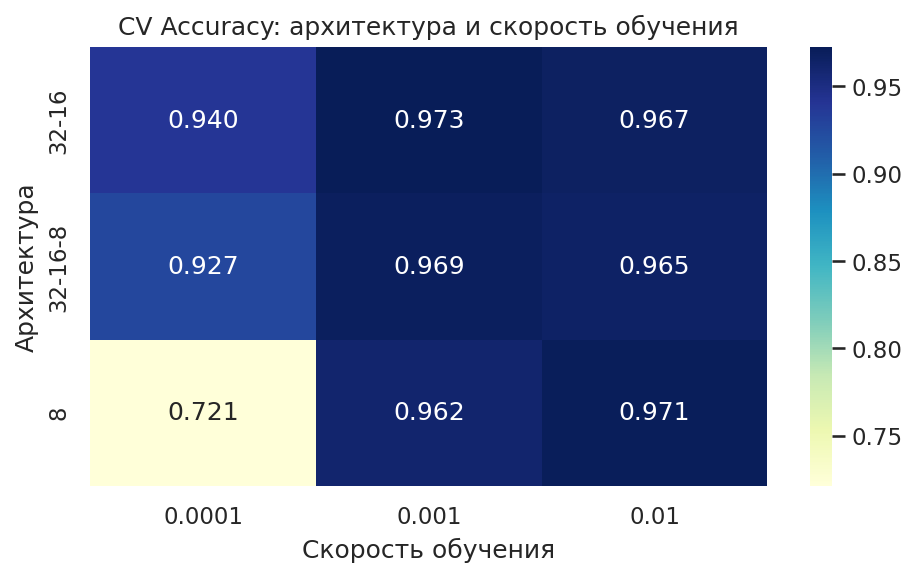

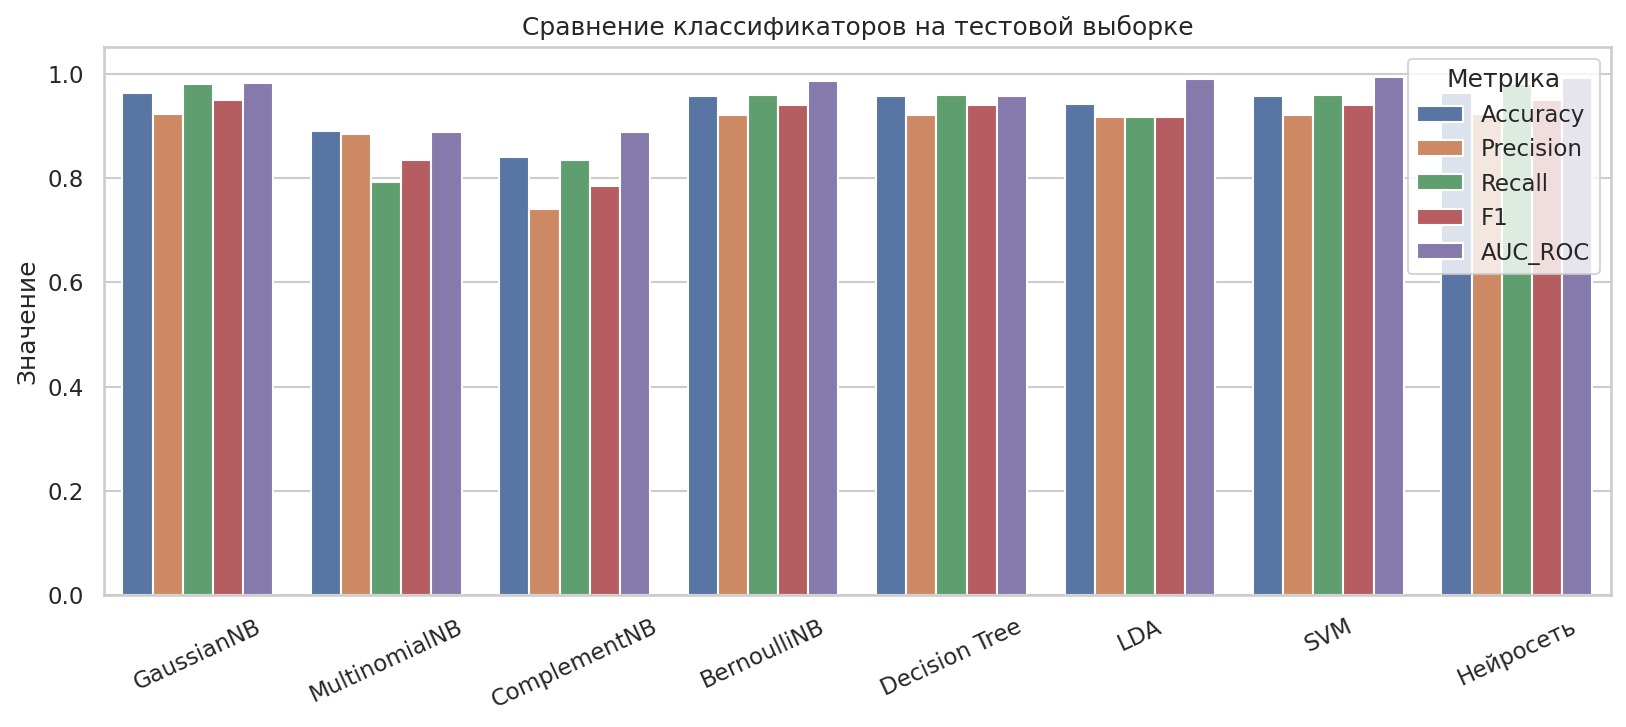

In [14]:
final_table = pd.DataFrame(results).set_index("Модель")
final_table = final_table.drop(columns=["CV F1"], errors="ignore")
final_table.to_csv(OUTPUT_DIR / "metrics_all.csv", encoding="utf-8-sig")
display(final_table.round(3))

heat = grid_table.pivot(index="Архитектура", columns="Скорость обучения", values="CV Accuracy")
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title("CV Accuracy: архитектура и скорость обучения")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "10_nn_grid.png", bbox_inches="tight")
plt.show()

plot_metrics = final_table.reset_index().melt(id_vars="Модель", value_vars=["Accuracy", "Precision", "Recall", "F1", "AUC_ROC"], var_name="Метрика", value_name="Значение")
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_metrics, x="Модель", y="Значение", hue="Метрика", ax=ax)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=25)
ax.set_ylim(0, 1.05)
ax.set_title("Сравнение классификаторов на тестовой выборке")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "11_final_comparison.png", bbox_inches="tight")
plt.show()


### Пояснение к кросс-валидации и подбору сети

- **Схема.** На обучающей выборке выполнена 5-кратная стратифицированная кросс-валидация. Сетка содержит 3 архитектуры (`8`, `32-16`, `32-16-8`) и 3 скорости обучения (0,0001, 0,001 и 0,01) — всего 9 конфигураций. Для каждого фолда TensorBoard пишет accuracy и loss в отдельный каталог.
- **Baseline.** Базовая сеть — один скрытый слой из 8 нейронов и скорость 0,001. Её средняя CV Accuracy равна **0,962**.
- **Лучшая конфигурация:** архитектура `32-16`, скорость обучения 0.001, CV Accuracy **0,973** (стандартное отклонение 0,010).
- **Эффект настройки.** Разница CV Accuracy между лучшей сеткой и baseline составляет **0,011**. На тесте baseline даёт Accuracy 0,971, а сеть, заново обученная с лучшими параметрами, — Accuracy = 0,964, Precision = 0,922, Recall = 0,979, F1 = 0,949, AUC-ROC = 0,992.
- Подбор архитектуры и скорости на этих данных не перестраивает качество радикально: цитологические оценки уже хорошо разделяются более простыми классификаторами. Сетка нужна, чтобы это проверить, а не чтобы автоматически получить большой прирост.


---
## Сравнительный анализ

На одной тестовой выборке лучший F1 получился сразу у нескольких моделей:

- **GaussianNB:** Accuracy = 0,964, Precision = 0,922, Recall = 0,979, F1 = 0,949, AUC-ROC = 0,982
- **Нейросеть:** Accuracy = 0,964, Precision = 0,922, Recall = 0,979, F1 = 0,949, AUC-ROC = 0,992

Лучшая классическая модель — **GaussianNB**: Accuracy = 0,964, Precision = 0,922, Recall = 0,979, F1 = 0,949, AUC-ROC = 0,982. Нейросеть после подбора архитектуры и скорости обучения даёт Accuracy = 0,964, Precision = 0,922, Recall = 0,979, F1 = 0,949, AUC-ROC = 0,992. Для этого датасета выигрыш нейросети над сильной линейной или байесовской моделью небольшой: девять упорядоченных оценок от 1 до 10 почти линейно связаны с диагнозом, а наблюдений после очистки только 683.

Recall здесь важнее точности «вообще»: пропуск злокачественного образца дороже лишней проверки доброкачественного. Поэтому модель с чуть меньшей Accuracy, но более высоким Recall, предпочтительнее, если разница F1 невелика. В полученной таблице этот компромисс уже учтён через F1 и AUC-ROC.

## Заключение

1. **Данные.** Использован набор Breast Cancer Wisconsin (Original) с Kaggle. После удаления 16 пропусков осталось 683 наблюдений. Целевой класс — злокачественная опухоль, таких случаев 239.
2. **Признаки.** Все девять оценок положительно связаны с диагнозом. Сильнее всего выделяется «Голые ядра».
3. **Байесовские модели.** Лучший вариант на тесте — GaussianNB (F1 = 0,949), рядом BernoulliNB. MultinomialNB и ComplementNB слабее: оценки от 1 до 10 не являются частотами. Параметр alpha влияет слабее, чем выбор распределения.
4. **Дерево, LDA и SVM.** Дерево начинает переобучаться при росте глубины. LDA почти не зависит от shrinkage. У SVM качество стабилизируется при умеренном `C`, а линейное и RBF-ядро близки.
5. **Нейросеть.** Сеть TensorFlow с сигмоидой на выходе и бинарной кросс-энтропией обучена с логами TensorBoard. Сетка из 3 архитектур и 3 скоростей обучения на 5 фолдах выбрала `32-16` и скорость 0.001. Прирост к baseline по CV Accuracy равен 0,011.
6. **Итог.** Для этого набора достаточно сильного классического метода. Нейросеть работает на том же уровне, но сложнее и не даёт содержательно новой точности. Метод k ближайших соседей не строился.

---
## Список использованных источников

1. Breast Cancer Wisconsin (Original) Data Set // Kaggle. URL: https://www.kaggle.com/datasets/mariolisboa/breast-cancer-wisconsin-original-data-set
2. Wolberg W. Breast Cancer Wisconsin (Original) // UCI Machine Learning Repository.
3. *Hastie T., Tibshirani R., Friedman J.* The Elements of Statistical Learning. 2nd ed. Springer, 2009.
4. Документация scikit-learn: Naive Bayes, Decision Trees, LDA, SVM. URL: https://scikit-learn.org/stable/supervised_learning.html
5. Документация TensorFlow Keras: https://www.tensorflow.org/guide/keras
6. Документация TensorBoard: https://www.tensorflow.org/tensorboard
